In [2]:
import pandas as pd

In [4]:
import os
print(os.getcwd())

c:\Users\hp\Documents\football_analysis\notebooks


In [5]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\hp\Documents\football_analysis\notebooks
['football_feature.ipynb']


In [7]:
import pandas as pd

In [9]:
df = pd.read_csv("../data/results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


The dataset contains historical international football match results including date,teams,scores and tournament

1.Basic exploration

How many matches are in the dataset

In [10]:
df.shape

(49071, 9)

shape returns the rows and columns.

rows=number of matches

The dataset contains X matches and Y variables

Earliest and latest year

In [12]:
df["date"]=pd.to_datetime(df["date"])
df["year"]=df["date"].dt.year
df["year"].min(),df["year"].max()

(1872, 2026)

In [13]:
df["date"]=pd.to_datetime(df["date"])
df["date"].min()
df["date"].max()

Timestamp('2026-01-26 00:00:00')

Number of unique countries

In [14]:
df["home_team"].nunique()

325

A better one for both home and away teams

In [16]:
teams = pd.concat([df["home_team"],
df["away_team"]])
teams.nunique()

333

There are X unique national teams appearing in the dataset

The most unique home team

In [18]:
df["home_team"].value_counts().head()

home_team
Brazil         610
Argentina      599
Mexico         596
Germany        552
South Korea    549
Name: count, dtype: int64

value_counts() counts the number of occurences of each team

2. Goal analysis


Create total goals

In [20]:
df["total_goals"] = df["home_score"] + df["away_score"]

Average goals per match

In [22]:
df["total_goals"].mean()

np.float64(2.938456522182144)

On average matches produce X goals

Highest scoring match


In [23]:
df.loc[df["total_goals"].idxmax()]

date                    2001-04-11 00:00:00
home_team                         Australia
away_team                    American Samoa
home_score                               31
away_score                                0
tournament     FIFA World Cup qualification
city                          Coffs Harbour
country                           Australia
neutral                               False
year                                   2001
total_goals                              31
Name: 25420, dtype: object

This returns the entire row of the highest scoring match

Home vs away goals

In [25]:
df["home_score"].sum()
df["away_score"].sum()


np.int64(58011)

In [26]:
df[["home_score","away_score"]].sum()


home_score    86182
away_score    58011
dtype: int64

Compares total goals scored by home and away teams

Most common total goals


In [27]:
df["total_goals"].value_counts().head()

total_goals
2    10896
3     9703
1     8496
4     6792
5     4228
Name: count, dtype: int64

Shows the mode of goals

3. Match results

Create result table

In [29]:
def match_results(row):
    if row["home_score"] >row["away_score"]:
        return "Home win"
    elif row["home_score"] < row["away_score"]:
        return "Away win"
    else:
        return "Draw"
    
df["result"] = df.apply(match_results,axis=1)    
        
    

In [8]:
def match_results(row):
    if row["home_score"] >row["away_score"]:
        return "Home win"
    elif row["home_score"] < row["away_score"]:
        return "Away win"
    else:
        return "Draw"
    
df["results"] = df.apply(match_results,axis=1)    
        
    

Percentage of home wins

In [31]:
df["result"].value_counts(normalize =True) * 100

result
Home win    48.996352
Away win    28.269243
Draw        22.734405
Name: proportion, dtype: float64

Or specifically

In [32]:
home_win_percentage = (df["result"] == "Home win").mean() * 100
home_win_percentage

np.float64(48.996352224328014)

Home wins account for X% of matches

Does home advantage exist

eg
If home wins significantly exceed away wins, it suggests home advantage

Show counts:

In [34]:
df["result"].value_counts()

result
Home win    24043
Away win    13872
Draw        11156
Name: count, dtype: int64

Country with most wins

Most only check the home wins. Strong analysis includes both home and away wins

Better method:

In [35]:
home_wins = df[df["result"]=="Home win"]
["home_team"]
away_wins = df[df["result"]== "Away_win"]
["away_team"]

wins = pd.concat([home_wins, away_wins])

wins.value_counts().head(10)

date        home_team               away_team      home_score  away_score  tournament                    city              country                 neutral  year  total_goals  result  
1873-03-08  England                 Scotland       4           2           Friendly                      London            England                 False    1873  6            Home win    1
2008-09-10  Bosnia and Herzegovina  Estonia        7           0           FIFA World Cup qualification  Zenica            Bosnia and Herzegovina  False    2008  7            Home win    1
            Oman                    Zimbabwe       3           2           Friendly                      Muscat            Oman                    False    2008  5            Home win    1
            New Zealand             New Caledonia  3           0           Oceania Nations Cup           North Shore       New Zealand             False    2008  3            Home win    1
            Mexico                  Canada         2        

4. Visualization

Histogram of goals

In [38]:
import matplotlib.pyplot as plt

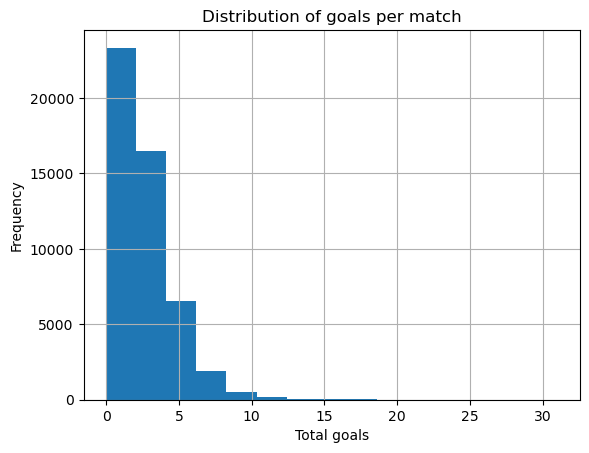

In [39]:
df["total_goals"].hist(bins=15)
plt.title("Distribution of goals per match")
plt.xlabel("Total goals")
plt.ylabel("Frequency")

plt.show()

The histogram shows the distribution of goals scored per match

Bar chart of match outcomes

In [4]:
import pandas as pd

In [5]:
df=pd.read_csv("../data/results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [10]:
import matplotlib.pyplot as plt

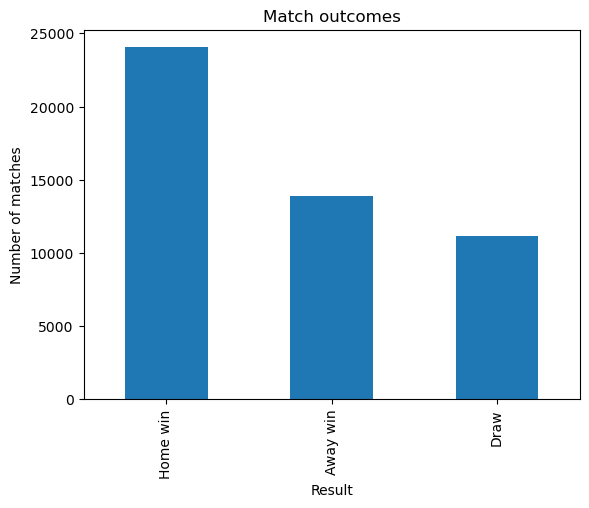

In [11]:
df["results"].value_counts().plot(kind="bar")

plt.title("Match outcomes")
plt.xlabel("Result")
plt.ylabel("Number of matches")
plt.show()


Top ten team by wins

Use the wins variable we created earlier

In [14]:
home_wins = df[df["results"]=="Home win"]
["home_team"]
away_wins = df[df["results"]== "Away_win"]
["away_team"]

wins = pd.concat([home_wins, away_wins])

wins.value_counts().head(10)

date        home_team               away_team      home_score  away_score  tournament                    city              country                 neutral  results 
1873-03-08  England                 Scotland       4           2           Friendly                      London            England                 False    Home win    1
2008-09-10  Bosnia and Herzegovina  Estonia        7           0           FIFA World Cup qualification  Zenica            Bosnia and Herzegovina  False    Home win    1
            Oman                    Zimbabwe       3           2           Friendly                      Muscat            Oman                    False    Home win    1
            New Zealand             New Caledonia  3           0           Oceania Nations Cup           North Shore       New Zealand             False    Home win    1
            Mexico                  Canada         2           1           FIFA World Cup qualification  Tuxtla Gutiérrez  Mexico                  False   

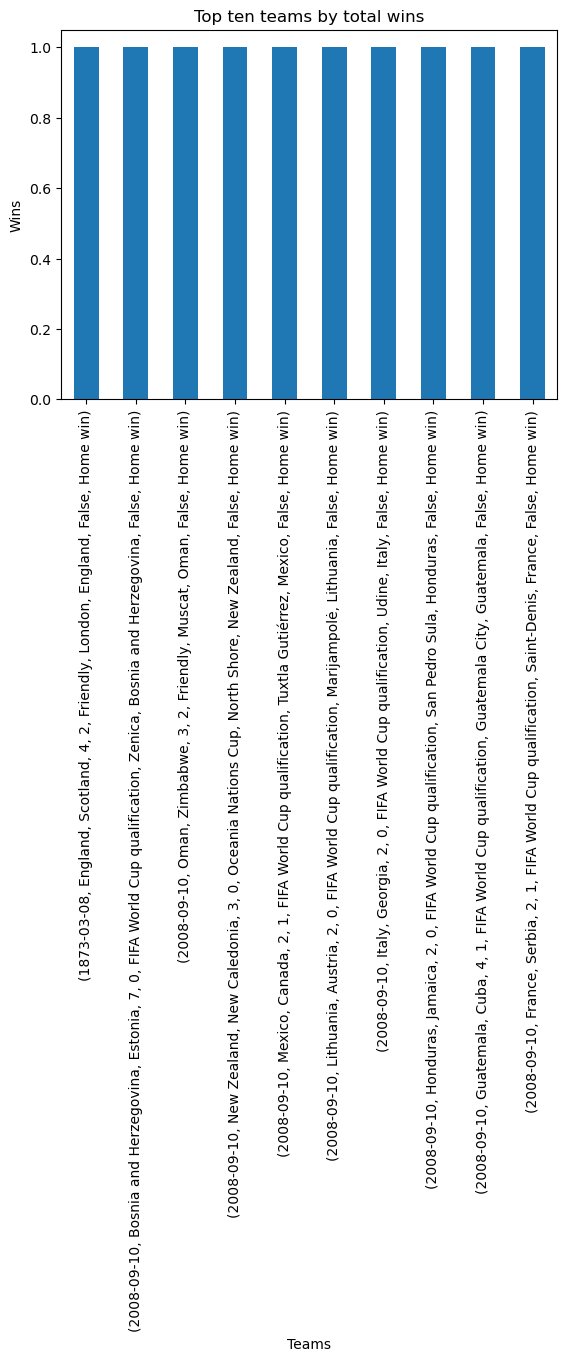

In [15]:
wins.value_counts().head(10).plot(kind="bar")
plt.title("Top ten teams by total wins")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.show()